In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import random
from scipy.stats import bernoulli

def simulate_one_poll(p, n_sample, seed=1):
    responses = stats.bernoulli.rvs(p=p, size=n_sample, random_state=seed)
    responses = pd.DataFrame(responses, columns=["response"])
    return responses
    

In [45]:
rng = np.random.default_rng(1)
prop_yes = None

df = simulate_one_poll(p=0.7, n_sample=100, seed=rng)
prop_yes = df['response'].mean()
prop_yes

np.float64(0.67)

In [39]:
rng = np.random.default_rng(1)

df = simulate_one_poll(0.7, 1000, rng)
prop_yes = df.mean()
prop_yes

response    0.687
dtype: float64

In [5]:
df.describe()

,response
count,1000.000000
mean,0.703000
std,0.457165
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [46]:
rng = np.random.default_rng(1)
p_true = 0.7
n_size = 100
n_simulations = 1000

all_means = []
for i in range(n_simulations):
    df = simulate_one_poll(p_true, n_size, seed=rng)
    all_means.append(df['response'].mean())

many_polls = pd.DataFrame(all_means, columns=['prop_yes'])

In [47]:
mean_prop_yes = None
std_prop_yes = None
percentile_5 = None
percentile_95 = None

many_polls.describe()

mean_prop_yes = many_polls['prop_yes'].mean()
std_prop_yes = many_polls['prop_yes'].std()
percentile_5 = many_polls['prop_yes'].quantile(0.05)
percentile_95 = many_polls['prop_yes'].quantile(0.95)

print(mean_prop_yes)
print(std_prop_yes)
print(percentile_5)
print(percentile_95)

0.69893
0.04714422210279514
0.62
0.77


In [20]:
def simulate_one_poll(p, n_sample, rng):
    # random_state now receives the object, not just a static seed
    responses = stats.bernoulli.rvs(p=p, size=n_sample, random_state=rng)
    return pd.DataFrame(responses, columns=["response"])


def simulate_many_polls(p, n_sample, n_simulations, seed=1):
    """
    Simulates many polls. To keep it reproducible across different 
    sample sizes, we reset the RNG at the start of the function.
    """
    # Create a fresh RNG starting at the provided seed
    # This ensures that simulate_many_polls(n_sample=10) and (n_sample=100)
    # start with the exact same sequence of random numbers.
    rng = np.random.default_rng(seed=seed)
    
    poll_data = []
    for _ in range(n_simulations):
        df_single_poll = simulate_one_poll(p, n_sample, rng)
        prop_yes = df_single_poll['response'].mean()
        
        poll_data.append({
            "prop_yes": prop_yes,
            "n_sample": n_sample
        })
    
    return pd.DataFrame(poll_data)

In [22]:
sample_sizes = [10, 100, 1000]
p_true = 0.7
n_sims = 1000

# 1. Use a list comprehension to run the simulation for each size
# We keep seed=1 constant so the underlying 'randomness' is reproducible
all_results_list = [
    simulate_many_polls(p=p_true, n_sample=n, n_simulations=n_sims, seed=1) 
    for n in sample_sizes
]

# 2. Combine them into one single DataFrame
sample_size_experiment = pd.concat(all_results_list, ignore_index=True)

# 3. View the result
print(sample_size_experiment.sample(5)) # Look at 5 random rows

      prop_yes  n_sample
1937     0.660       100
2364     0.684      1000
146      0.600        10
2337     0.714      1000
1264     0.740       100


In [28]:
sample_size_summary = sample_size_experiment.groupby('n_sample').agg({'mean','std'})

In [30]:
sample_size_experiment.describe()

,prop_yes,n_sample
count,3000.000000,3000.00000
mean,0.698252,370.00000
std,0.090387,447.06445
min,0.200000,10.00000
25%,0.680000,10.00000
50%,0.700000,100.00000
75%,0.720000,1000.00000
max,1.000000,1000.00000


In [31]:
sample_size_summary

prop_yes          
               std      mean
n_sample                    
10        0.148650  0.696100
100       0.047144  0.698930
1000      0.014106  0.699727

In [35]:
def plot_continuous(
    data, ax1, num_bins=100, label_precision=2, min_val=0, max_val=1, max_prob=None
):
    # Create the bar plot on the first y-axis

    # filter out the data outside the min_val and max_val range
    data = data[(data["n_sample"] >= min_val) & (data["n_sample"] <= max_val)]

    # define the bin edges
    bin_edges = np.linspace(min_val, max_val, num_bins + 1)
    data["bin"], bin_ranges = pd.cut(data["n_sample"], bins=bin_edges, retbins=True)
    counts = data.groupby("bin", observed=False).size()
    probs = counts / counts.sum()
    # use the left edge of each bin_range as the x-axis labels, rounded to the nearest 2 decimal places
    left_edges = bin_ranges[:-1]
    # round the labels to 2 decimal places
    labels = np.round(left_edges, label_precision)

    sns.barplot(x=labels, y=probs, ax=ax1)
    # set maximum probability value if provided
    if max_prob:
        ax1.set_ylim(0, max_prob)

    # Only show every 10th label on the x-axis, for better readability
    for ind, label in enumerate(ax1.get_xticklabels()):
        if ind % 10 == 0:  # every 10th label is kept
            label.set_visible(True)
        else:
            label.set_visible(False)
        # Set y-axis label to "Probability"

    ax1.set_ylabel("Probability")

KeyError: 'n_sample'

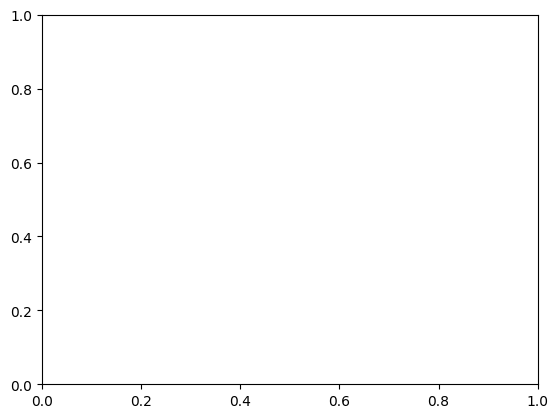

In [36]:
plot_continuous(sample_size_summary, plt.gca())